In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings
warnings.filterwarnings("ignore")

xr.set_options(keep_attrs=True)
print("xarray", xr.__version__)

xarray 2024.5.0


## 1. Configuration

In [2]:
CF_THRESHOLD = 0.10

LON_MIN, LON_MAX =  110, 155
LAT_MIN, LAT_MAX =  -45, -10
LON_MIN_SE, LON_MAX_SE = 134, 153
LAT_MIN_SE, LAT_MAX_SE = -25, -39

CF_DIR   = "/g/data/w42/dr6273/work/projects/Aus_energy/production_metrics/wind/capacity_factor/van_der_Wiel/"
SWTLIBDIR = "/g/data/gb02/mb0427/Australian_synoptic_weather_types/"
OUT_DIR  = "/g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/dominant_swt/"
os.makedirs(OUT_DIR, exist_ok=True)

SEASONS = {"DJF": [12,1,2], "MAM": [3,4,5], "JJA": [6,7,8], "SON": [9,10,11]}

YEAR_START, YEAR_END = 1980, 2020
print("Config OK")

Config OK


## 2. Helper functions

In [3]:
def get_time_name(o):
    for c in ("time", "valid_time", "t"):
        if c in o.dims: return c
    raise KeyError("no time dim")

def get_lat_name(o):
    for c in ("latitude", "lat", "y"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lat")

def get_lon_name(o):
    for c in ("longitude", "lon", "x"):
        if c in o.coords or c in o.dims: return c
    raise KeyError("no lon")

def subset_domain(da):
    laname, loname = get_lat_name(da), get_lon_name(da)
    lat = da[laname].values
    lat_slice = slice(LAT_MAX+0.5, LAT_MIN-0.5) if lat[0] > lat[-1] \
                else slice(LAT_MIN-0.5, LAT_MAX+0.5)
    return da.sel({loname: slice(LON_MIN-0.5, LON_MAX+0.5), laname: lat_slice})

## 3. SWT colors (Barnes et al. 2025)

In [4]:
SWT_COLORS = {
    "WH-A": "#8B0000", "WH-B": "#FF00FF", "WH-C": "#FF99FF", "WH-D": "#FFE5FF",
    "CH-A": "#FFD700", "CH-B": "#FFE680",
    "EH-A": "#8B1A1A", "EH-B": "#CD3333", "EH-C": "#E88080",
    "EH-D": "#F4AAAA", "EH-E": "#FFD0D0",
    "TH-A": "#8B4513", "TH-B": "#CD853F", "TH-C": "#FFDAB9",
    "FH-A": "#4CAF50", "FH-B": "#8BC34A", "FH-C": "#C5E1A5",
    "WCT-A": "#2B0DB5", "WCT-B": "#9B80E0",
    "COL-A": "#0D3B6E", "COL-B": "#1A7AAF", "COL-C": "#2196F3",
    "COL-D": "#64B5F6", "COL-E": "#90CAF9", "COL-F": "#C8E6FF",
    "AM-A":  "#004D40", "AM-B":  "#00695C", "AM-C":  "#00ACC1",
    "AM-D":  "#80CBC4", "AM-E":  "#E0F7F4",
}
print(f"{len(SWT_COLORS)} SWT colors defined")

30 SWT colors defined


## 4. Loading SWT labels

In [5]:
from datetime import datetime

ds_clim   = xr.open_dataset(f"{SWTLIBDIR}SWT_climatology/SWT_climatology.nc")
SWT_LIST  = list(ds_clim.SWTs.values)
N_SWT     = len(SWT_LIST)
SWT_INDEX = {name: i for i, name in enumerate(SWT_LIST)}

swt_time_all  = pd.DatetimeIndex(ds_clim.time.values)
swt_label_all = ds_clim["assigned_SWT"].values

mask_period = (swt_time_all >= pd.Timestamp(f"{YEAR_START}-01-01")) & \
              (swt_time_all <= pd.Timestamp(f"{YEAR_END}-12-31"))
swt_time_all  = swt_time_all[mask_period]
swt_label_all = swt_label_all[mask_period]

swt_by_date = {ts.date(): lbl for ts, lbl in zip(swt_time_all, swt_label_all)}

missing = [s for s in SWT_LIST if s not in SWT_COLORS]
print(f"{len(SWT_LIST)} SWTs loaded")
print("Missing colors:", missing if missing else "None")

30 SWTs loaded
Missing colors: None


## 5. Loading of CF 1980-2020 with cache

In [7]:
CACHE_PATH = os.path.join(OUT_DIR, "cf_daily_all_cache.nc")

if os.path.exists(CACHE_PATH):
    print("Loading from cache...")
    cf_daily_all = xr.open_dataset(CACHE_PATH)["cf"].load()
else:
    print("Building daily CF from van der Wiel files...")
    cf_files = [
        f"{CF_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{yr}_Aus.nc"
        for yr in range(YEAR_START, YEAR_END + 1)
        if os.path.exists(f"{CF_DIR}wind_capacity_factor_van_der_Wiel_era5_hourly_{yr}_Aus.nc")
    ]
    print(f"  {len(cf_files)} files found")

    ds_all  = xr.open_mfdataset(cf_files, combine="by_coords", chunks={"time": 24*30})
    cf_var  = [v for v in ds_all.data_vars if ds_all[v].ndim >= 3][0]
    cf_all  = subset_domain(ds_all[cf_var])
    tname_  = get_time_name(cf_all)

    cf_daily_all = cf_all.resample({tname_: "1D"}).mean().astype("float32").load()
    cf_daily_all.rename("cf").to_netcdf(CACHE_PATH)
    print("  Cache saved:", CACHE_PATH)

tname_all    = get_time_name(cf_daily_all)
lat_name_all = get_lat_name(cf_daily_all)
lon_name_all = get_lon_name(cf_daily_all)
cf_lat_all   = cf_daily_all[lat_name_all].values
cf_lon_all   = cf_daily_all[lon_name_all].values
time_cf      = pd.DatetimeIndex(cf_daily_all[tname_all].values)

print("CF daily shape:", cf_daily_all.shape)

Building daily CF from van der Wiel files...
  41 files found
  Cache saved: /g/data/m35/qr1706/Conferences/Graduate Colloquium 2026/Output/dominant_swt/cf_daily_all_cache.nc
CF daily shape: (14976, 141, 181)


## 6. calculation of the dominant SWT per pixel and by season

In [8]:
cf_vals = cf_daily_all.values   # (ntime, nlat, nlon)
month_arr = time_cf.month

swt_int = np.array([
    SWT_INDEX.get(swt_by_date.get(d.date(), None), -1)
    for d in time_cf
], dtype=np.int32)

def dominant_drought_swt(season_months):
    """
    For each grid cell, find the SWT that occurs most often
    during drought days in the given season.
    Returns NaN where no drought days occurred.
    """
    mask  = np.isin(month_arr, season_months) & (swt_int >= 0)
    cf_s  = cf_vals[mask]
    swt_s = swt_int[mask]
    nlat, nlon = cf_s.shape[1], cf_s.shape[2]
    counts = np.zeros((N_SWT, nlat, nlon), dtype=np.int32)
    for t in range(len(swt_s)):
        drought_cells = (cf_s[t] < CF_THRESHOLD)
        counts[swt_s[t]] += drought_cells.astype(np.int32)
    total    = counts.sum(axis=0)
    dominant = np.argmax(counts, axis=0).astype(float)
    dominant[total == 0] = np.nan
    return dominant

print("Computing dominant SWT per grid cell and season...")
dominant = {"ANN": dominant_drought_swt(list(range(1, 13)))}
for season, months in SEASONS.items():
    dominant[season] = dominant_drought_swt(months)
    print(f"  {season} done")
print("Done.")

Computing dominant SWT per grid cell and season...
  DJF done
  MAM done
  JJA done
  SON done
Done.


## 7. Plot

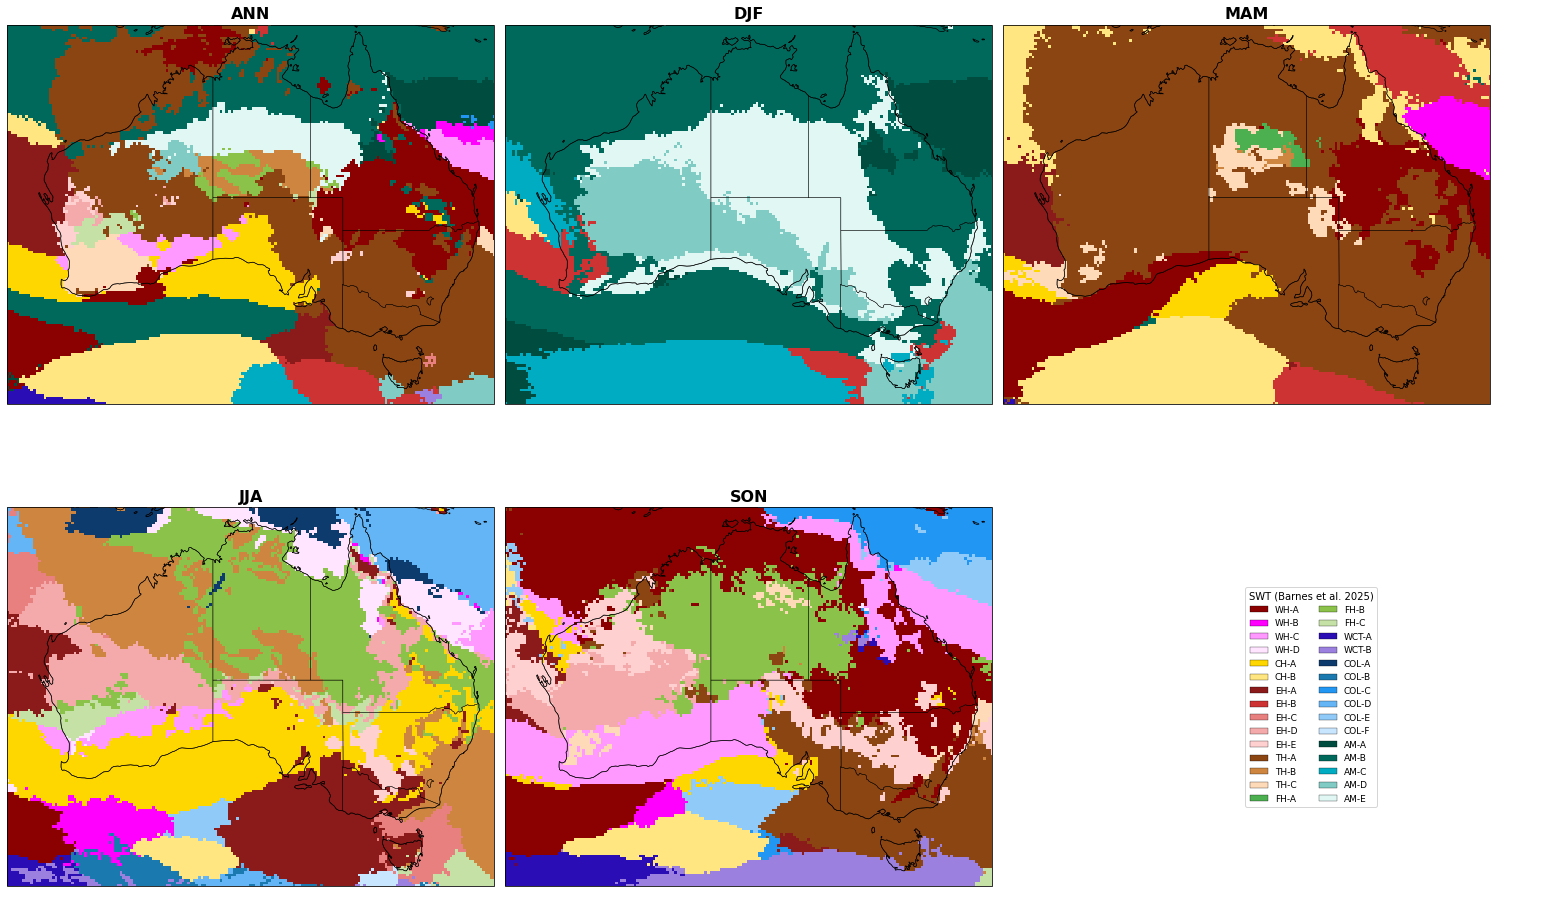

In [10]:
cmap_colors = [SWT_COLORS[s] for s in SWT_LIST]
cmap = ListedColormap(cmap_colors)
bounds = np.arange(-0.5, N_SWT + 0.5, 1)
norm  = BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(2, 3, figsize=(22, 14),
                         subplot_kw={"projection": ccrs.PlateCarree()})
axes = axes.flat

for ax, key in zip(axes, ["ANN", "DJF", "MAM", "JJA", "SON"]):
    field = dominant[key]
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.05, zorder=0)
    ax.add_feature(cfeature.OCEAN, alpha=0.1, zorder=0)
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    ax.pcolormesh(cf_lon_all, cf_lat_all, field,
                  cmap=cmap, norm=norm,
                  transform=ccrs.PlateCarree(), shading="auto")
    ax.set_title(key, fontsize=16, fontweight="bold")

# Last panel -> legend
axes[5].set_visible(False)
ax_leg = fig.add_axes([0.68, 0.05, 0.30, 0.42])
ax_leg.axis("off")
handles = [Patch(facecolor=SWT_COLORS[s], edgecolor="k", lw=0.3, label=s)
           for s in SWT_LIST]
ax_leg.legend(handles=handles, loc="center", ncol=2, fontsize=9,
              frameon=True, title="SWT (Barnes et al. 2025)",
              title_fontsize=10)

fig.suptitle(
    f"Dominant SWT during wind drought (CF < {CF_THRESHOLD}) per grid cell\n"
    f"1980–2020  |  van der Wiel ERA5",
    fontsize=16, y=1.01,
)
fig.tight_layout(rect=[0, 0, 0.95, 1])
fig.savefig(os.path.join(OUT_DIR, "dominant_swt_drought_map.png"),
            dpi=150, bbox_inches="tight")
plt.show()